## MVP for GrowBikeNet implementation

In [1]:
# import libraries
import osmnx as ox

# import functions
from growbikenet.functions import *

# import visualization
from growbikenet.visualizations import *

In [4]:
def growbikenet(
        city_name,
        proj_crs,
        ranking,
        #seed_point_type="grid",
        seed_point_spacing=1707,
        seed_point_delta=500,
        export_data=True,
        export_plots=False,
        export_video=False,
):
        """
    creates list of edges that form city network, ordered by specified ranking method

    Parameters
    ----------
    city_name : str
        name of the city that the analysis should be performed on
    proj_crs : str
        coordinate reference system that is used to project osm data
    ranking : str
        method used to rank edges
    seed_point_spacing : int, optional
        spacing between seed points, in meters
    seed_point_delta : int, optional
        maximum distance between generated seed points and osm nodes for snapping
    export_data : bool, optional
        if set to 'True' data will be saved to a file
    export_plots : bool, optional
        if set to 'True' plots will be saved to a file
    export_video : bool, optional
        if set to 'True' video will be saved to a file (only possible if export_plots is set to True)

    Returns
    -------
    a_edges : geopandas.geodataframe.GeoDataFrame
        ordered geodataframe of all edges in street network

    """
        # check if user input is valid
        if type(city_name) != str:
            raise TypeError("city_name must be a string")
        if type(proj_crs) != str:
            raise TypeError("proj_crs must be a string")
        if type(ranking) != str:
            raise TypeError("ranking must be a string")
        if ranking != 'betweenness_centrality' and ranking != 'closeness_centrality':
            raise ValueError("ranking must be 'betweenness_centrality' or 'closeness_centrality'")
        if type(seed_point_spacing) != int:
            raise TypeError("seed_point_spacing must be an integer")
        if type(seed_point_delta) != int:
            raise TypeError("seed_point_delta must be an integer")
        if type(export_data) != bool:
            raise TypeError("export_data must be a boolean")
        if type(export_plots) != bool:
            raise TypeError("export_plots must be a boolean")
        if type(export_video) != bool:
            raise TypeError("export_video must be a boolean")


        ### getting and preprocessing data from OSM
        print("getting osm data")

        # fetch street network data from osmnx
        g = ox.graph_from_place(
        city_name, network_type='all'
        )
        g_undir = g.to_undirected().copy() # convert to undirected (dropping OSMnx keys!)

        # export osmnx data to gdfs
        nodes, edges = ox.graph_to_gdfs(
        g_undir,
        nodes=True,
        edges=True,
        node_geometry=True,
        fill_edge_geometry=True
        )

        # # save "original" graph data (in orig_crs)
        # nodes.to_file("nodes.gpkg", driver='GPKG')
        # edges.to_file("edges.gpkg", driver='GPKG')

        # replace after dropping edges with key = 1
        edges = edges.loc[:,:,0].copy()
        # this also means we are dropping the "key" level from edge index (u,v,key becomes: u,v)

        # project geometries of nodes, edges, seed points
        edges = edges.to_crs(proj_crs)
        nodes = nodes.to_crs(proj_crs)

        # add osm ID as column to node gdf
        nodes["osmid"] = nodes.index

        ### creating seed points
        print("making seed points")

        # Bearings work on unprojected graph
        ox.bearing.add_edge_bearings(g_undir)
        principal_bearing = get_principal_bearing(g_undir)

        # But this is on the projected edges now
        seed_points = get_seed_points(edges, seed_point_spacing, principal_bearing)

        # Snap seed points to OSM nodes
        seed_points_snapped = snap_seed_points(seed_points, nodes)
        seed_points_snapped = filter_seed_points(seed_points_snapped, seed_point_delta)

        ### running greedy triangulation
        print("greedy triangulation")

        # create df with all potential edges in triangulation
        df = create_potential_triangulation(seed_points_snapped)

        # filter edges that intersect with existing edges
        edge_list = filter_triangulation(df)

        # make graph object from edge list
        A = nx.Graph()
        A.add_nodes_from(seed_points_snapped.index)
        A.add_edges_from(edge_list)

        ### compute edge attributes
        print("edge attributes")

        if ranking == 'betweenness_centrality':
                # add betweenness attributes to edges
                bc_values = nx.edge_betweenness_centrality(A, normalized=True)
                nx.set_edge_attributes(A, bc_values, name='betweenness_centrality')

        elif ranking == 'closeness_centrality':
                # add closeness attributes to nodes and edges
                cc_values_nodes = nx.closeness_centrality(A)
                nx.set_node_attributes(A, cc_values_nodes, name='closeness_centrality')

                cc_values = node_to_edge_attributes(cc_values_nodes, A.edges)
                nx.set_edge_attributes(A, cc_values, name='closeness_centrality')

        # export attributes to gdfs:

        # create dataframe and add method as edge attribute
        a_edges = df_from_graph(A, ranking)

        # rank edges by specified method
        a_edges = rank_df(a_edges, ranking)

        # map each abstract edge to a merged geometry of corresponding osmnx edges (routed on g_undir)
        a_edges = add_path_to_df(a_edges, edges, g_undir)

        ### route abstract edges on street network
        print("routing")

        # get "routed" geometry (LineString) for each abstract edge (row)
        a_edges = create_gdf_with_geoms(a_edges, edges)

        ### save data
        print("data save")
        # save to file
        if export_data:
                a_edges.to_file("a_edges.gpkg", driver="GPKG")

        ### Visualization
        print("viz")

        if export_plots or export_video:
                # create directories
                os.makedirs("./results/", exist_ok=True)
                os.makedirs("./results/plots/", exist_ok=True)
                os.makedirs("./results/plots/video/", exist_ok=True)

                # read in file to plot
                routed_edges_gdf = gpd.read_file("a_edges.gpkg")

                # viz/plot settings (move to config file later)

                # define color palette (from Michael's project: https://github.com/mszell/bikenwgrowth/blob/main/parameters/parameters.py)
                streetcolor = "#999999"
                edgecolor = "#0EB6D2"
                seedcolor = "#ff7338"

                # define linewidths

                lws = {
                "street": 0.75,
                "bike": 2
                }

                create_plots(routed_edges_gdf,seed_points_snapped,streetcolor,edgecolor,seedcolor,lws)
                if export_video:
                        print("video")
                        make_video(
                                img_folder_name="./results/plots/",
                                fps = 1
                        )

        return a_edges


In [8]:
a_edges = growbikenet(
    city_name="Manhattan",
    proj_crs = '3857',
    ranking = 'betweenness_centrality',
    export_plots = True,
    export_video = True
)

TypeError: proj_crs must be a string

In [6]:
a_edges.head()

,betweenness_centrality,source,target,ordering,path_nodes,path_edges,geometry
0,0.125093,1684212082,2329911577,0,"[1684212082, 1684212065, 9789372032, 797342055...","[(1684212065, 1684212082), (1684212065, 978937...","LINESTRING (-8234895.31 4982766.35, -8234903.5..."
1,0.121051,2329911577,9441264823,1,"[2329911577, 2329911544, 3831472009, 232991148...","[(2329911544, 2329911577), (2329911544, 383147...","LINESTRING (-8235757.134 4981236.211, -8235762..."
2,0.115866,3640160392,13287367597,2,"[3640160392, 3640160521, 9075216670, 857314524...","[(3640160392, 3640160521), (3640160521, 907521...","LINESTRING (-8229523.811 4981678.324, -8229520..."
3,0.115096,13287367597,5174914590,3,"[13287367597, 4999924588, 348445379, 348445161...","[(4999924588, 13287367597), (348445379, 499992...","MULTILINESTRING ((-8235540.885 4971293.809, -8..."
4,0.087135,10128889849,1684212082,4,"[10128889849, 10128785461, 10128785460, 101287...","[(10128785461, 10128889849), (10128785460, 101...","LINESTRING (-8233122.97 4985731.161, -8233133...."


<Axes: >

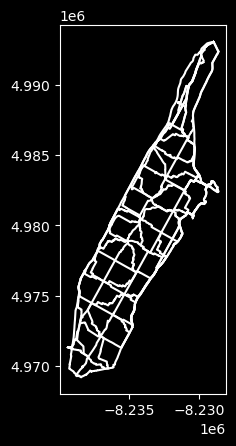

In [7]:
a_edges.plot()